
# Notebook tutorial - nutrición, redes sociales y Modelo de Creencias en Salud

Este notebook está pensado como una **introducción guiada** a una forma de trabajo muy concreta:

**artículos -> modelo conceptual -> variables -> datos sintéticos -> análisis -> interpretación**

No utiliza datos reales. Utiliza un conjunto de **datos sintéticos** creado para enseñar cómo un modelo conceptual puede traducirse en una estructura analítica.

## Qué debería aprender el estudiantado

Al finalizar este recorrido, debería poder:

- entender qué se toma de varios artículos para construir un modelo docente
- identificar los principales constructos del **Modelo de Creencias en Salud (MCS)**
- ver cómo una variable relacionada con desinformación puede integrarse en el modelo
- comprender cómo se generan datos sintéticos alineados con una teoría
- interpretar análisis descriptivos, correlaciones, regresión lineal y una clasificación básica



## 1. Los tres artículos de partida

### Artículo 1
Aporta la lógica general **redes sociales -> percepciones -> conducta**. Nos ayuda a justificar que la exposición a contenido en redes sociales puede influir en creencias y, a través de ellas, en la conducta.

### Artículo 2
Aporta la conexión específica entre **nutrición**, **redes sociales** y varios constructos del Modelo de Creencias en Salud, especialmente **barreras percibidas**, **claves para la acción** y **autoeficacia**.

### Artículo 3
Aporta una base clara para la parte nutricional del modelo, reforzando el papel de **beneficios percibidos**, **autoeficacia** y **claves para la acción** como predictores de resultados alimentarios.

## Idea clave
Ningún artículo, por sí solo, resuelve exactamente el caso docente que queremos estudiar. Por eso construimos un **modelo docente adaptado**.



## 2. El Modelo de Creencias en Salud adaptado

Este es el modelo docente que usaremos:

```text
Exposición a contenido nutricional en redes sociales
                    |
                    v
Credibilidad percibida de contenido nutricional dudoso
     |              |              |              |
     v              v              v              v
Beneficios     Barreras      Autoeficacia   Claves para la acción
percibidos     percibidas
     \              |              |              /
      \             |              |             /
                 v
  Intención de seguir consejos nutricionales vistos en redes
                 |
                 v
  Alta vs baja intención de seguir consejos dudosos
```

## Qué hemos añadido nosotros
La variable **credibilidad percibida de contenido nutricional dudoso** se incorpora porque es especialmente importante en el contexto de redes sociales y desinformación.



## 3. De constructos a variables

En investigación, un **constructo** es un concepto del modelo. Para analizarlo necesitamos una **variable**.

| Constructo | Variable |
|---|---|
| Exposición a contenido nutricional en redes | `social_media_exposure` |
| Credibilidad del contenido dudoso | `credibility_dubious_content` |
| Beneficios percibidos | `perceived_benefits` |
| Barreras percibidas | `perceived_barriers` |
| Autoeficacia | `self_efficacy` |
| Claves para la acción | `cues_to_action` |
| Intención de seguir consejos | `intention_follow_advice` |
| Alta intención de seguir consejos dudosos | `high_risk_following_intention` |



## 4. Cómo generaremos datos sintéticos

No queremos generar números al azar sin sentido. Queremos generar datos que sigan la lógica del modelo.

### Pasos
1. Generar la exposición a contenido nutricional en redes
2. Generar la credibilidad del contenido dudoso a partir de la exposición
3. Generar beneficios, barreras, autoeficacia y claves para la acción
4. Generar la intención de seguir consejos a partir de esas variables
5. Derivar una versión binaria para hacer una clasificación básica

### Importante
Estos datos **no describen una población real**. Sirven para aprender cómo se relacionan teoría, variables y análisis.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

np.random.seed(42)
sns.set_theme(style="whitegrid")


## 5. Generador de datos sintéticos

La función siguiente crea un conjunto de datos con relaciones alineadas con el modelo conceptual.

No hace falta entender cada línea al detalle. Lo importante es fijarse en la lógica:

- unas variables se generan primero
- otras dependen de las anteriores
- la intención final depende de varias rutas a la vez


In [10]:

def clip_scale(x, low=1, high=5):
    return np.clip(x, low, high)

def generate_dataset(n=400):
    social_media_exposure = clip_scale(np.random.normal(3.0, 0.9, n))
    nutrition_interest = clip_scale(np.random.normal(3.2, 0.8, n))
    supplement_use_history = np.random.binomial(1, 0.35, n)

    # Efecto con ligera saturación
    exposure_effect = 0.9 * np.tanh((social_media_exposure - 2.5) / 1.2)
    credibility_dubious_content = clip_scale(
        2.6 + exposure_effect + 0.35 * supplement_use_history + np.random.normal(0, 0.45, n)
    )

    perceived_benefits = clip_scale(
        1.8 + 0.55 * credibility_dubious_content + 0.20 * social_media_exposure + np.random.normal(0, 0.5, n)
    )

    perceived_barriers = clip_scale(
        3.2 - 0.25 * nutrition_interest + 0.15 * credibility_dubious_content + np.random.normal(0, 0.55, n)
    )

    cues_to_action = clip_scale(
        1.9 + 0.45 * social_media_exposure + 0.25 * credibility_dubious_content + np.random.normal(0, 0.5, n)
    )

    self_efficacy = clip_scale(
        2.6 + 0.45 * nutrition_interest - 0.35 * perceived_barriers + np.random.normal(0, 0.45, n)
    )

    intention_follow_advice = clip_scale(
        0.8
        + 0.28 * credibility_dubious_content
        + 0.24 * perceived_benefits
        - 0.18 * perceived_barriers
        + 0.25 * self_efficacy
        + 0.22 * cues_to_action
        + np.random.normal(0, 0.35, n)
    )

    threshold = np.quantile(intention_follow_advice, 0.65)
    high_risk_following_intention = (intention_follow_advice >= threshold).astype(int)

    df = pd.DataFrame({
        'social_media_exposure': social_media_exposure,
        'nutrition_interest': nutrition_interest,
        'supplement_use_history': supplement_use_history,
        'credibility_dubious_content': credibility_dubious_content,
        'perceived_benefits': perceived_benefits,
        'perceived_barriers': perceived_barriers,
        'cues_to_action': cues_to_action,
        'self_efficacy': self_efficacy,
        'intention_follow_advice': intention_follow_advice,
        'high_risk_following_intention': high_risk_following_intention,
    })
    return df

df = generate_dataset()
df.head()


,social_media_exposure,nutrition_interest,supplement_use_history,credibility_dubious_content,perceived_benefits,perceived_barriers,cues_to_action,self_efficacy,intention_follow_advice,high_risk_following_intention
0,3.447043,1.924458,0,3.604509,4.983920,3.568068,4.677521,2.497114,3.971153,0
1,2.875562,2.720500,1,3.378741,4.529684,2.864172,3.287148,3.419785,4.098690,1
2,3.582920,3.204195,0,3.694837,4.937925,3.336502,4.961997,3.048176,4.025357,1
3,4.370727,3.237584,0,2.120409,3.564777,2.525064,3.897899,3.664082,3.867752,0
4,2.789262,2.839948,0,3.752609,4.012688,3.698123,3.901334,3.489155,4.456014,1



## 6. Primera inspección del dataset

Antes de hacer análisis más formales, conviene mirar:

- cuántas filas y columnas hay
- qué variables contiene
- qué valores medios aparecen


In [11]:

print(df.shape)
df.describe().T


(400, 10)


,count,mean,std,min,25%,50%,75%,max
social_media_exposure,400.0,3.017942,0.838810,1.000000,2.410101,3.053298,3.567631,5.000000
nutrition_interest,400.0,3.165202,0.794852,1.042491,2.599831,3.172903,3.697656,5.000000
supplement_use_history,400.0,0.377500,0.485369,0.000000,0.000000,0.000000,1.000000,1.000000
credibility_dubious_content,400.0,3.046753,0.669512,1.275065,2.606889,3.060574,3.541802,4.937487
perceived_benefits,400.0,4.069687,0.637120,2.256465,3.634649,4.069533,4.603507,5.000000
perceived_barriers,400.0,2.860822,0.581385,1.095115,2.468595,2.886360,3.215557,5.000000
cues_to_action,400.0,3.999778,0.643468,2.300466,3.546904,3.964755,4.520097,5.000000
self_efficacy,400.0,3.018535,0.638583,1.517537,2.557044,3.030195,3.507249,4.564051
intention_follow_advice,400.0,3.748892,0.577853,2.226838,3.358675,3.743386,4.160777,5.000000
high_risk_following_intention,400.0,0.350000,0.477567,0.000000,0.000000,0.000000,1.000000,1.000000



### Preguntas tutoriales

1. ¿Qué variables parecen tener medias más altas?
2. ¿Qué variables parecen más dispersas?
3. ¿Tiene sentido que todas estén en rangos parecidos?



## 7. Visualización descriptiva

Empezamos con algunas distribuciones sencillas. El objetivo es tomar contacto con las variables antes de modelizar.


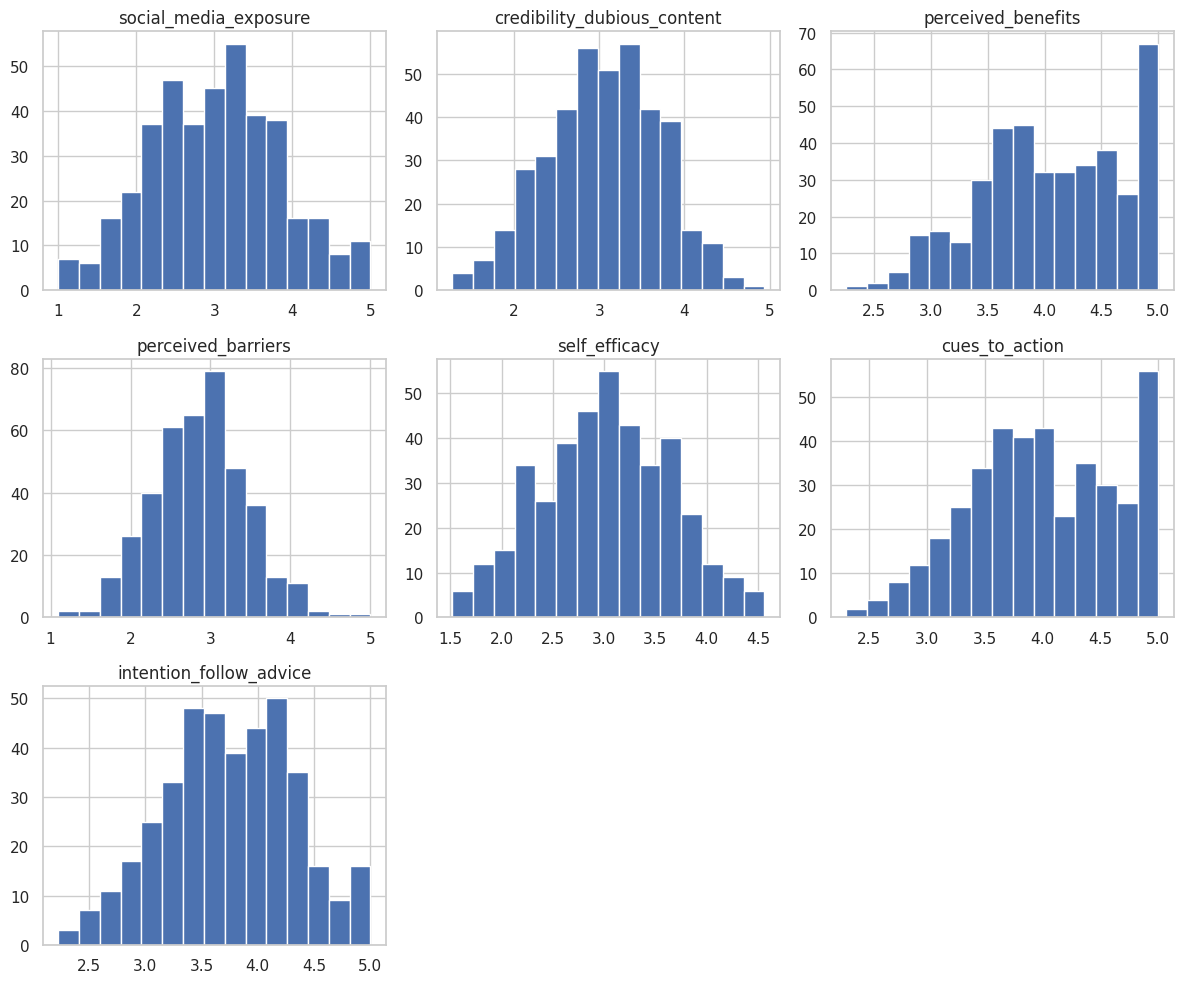

In [12]:

cols = ['social_media_exposure', 'credibility_dubious_content', 'perceived_benefits',
        'perceived_barriers', 'self_efficacy', 'cues_to_action', 'intention_follow_advice']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    ax.hist(df[col], bins=15)
    ax.set_title(col)
for ax in axes[len(cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()



### Preguntas tutoriales

1. ¿Qué variables parecen más centradas en valores altos?
2. ¿Hay distribuciones especialmente estrechas o amplias?
3. ¿Qué variable crees que será más importante para explicar la intención final?



## 8. Correlaciones

Ahora observamos si las relaciones entre variables son compatibles con el modelo conceptual.


In [13]:

corr = df[cols].corr()
corr


,social_media_exposure,credibility_dubious_content,perceived_benefits,perceived_barriers,self_efficacy,cues_to_action,intention_follow_advice
social_media_exposure,1.000000,0.634628,0.543929,0.134016,-0.155208,0.697557,0.490034
credibility_dubious_content,0.634628,1.000000,0.679445,0.171384,-0.111792,0.600513,0.588283
perceived_benefits,0.543929,0.679445,1.000000,0.055444,-0.040658,0.453188,0.595580
perceived_barriers,0.134016,0.171384,0.055444,1.000000,-0.479901,0.109787,-0.208384
self_efficacy,-0.155208,-0.111792,-0.040658,-0.479901,1.000000,-0.059417,0.299576
cues_to_action,0.697557,0.600513,0.453188,0.109787,-0.059417,1.000000,0.543975
intention_follow_advice,0.490034,0.588283,0.595580,-0.208384,0.299576,0.543975,1.000000


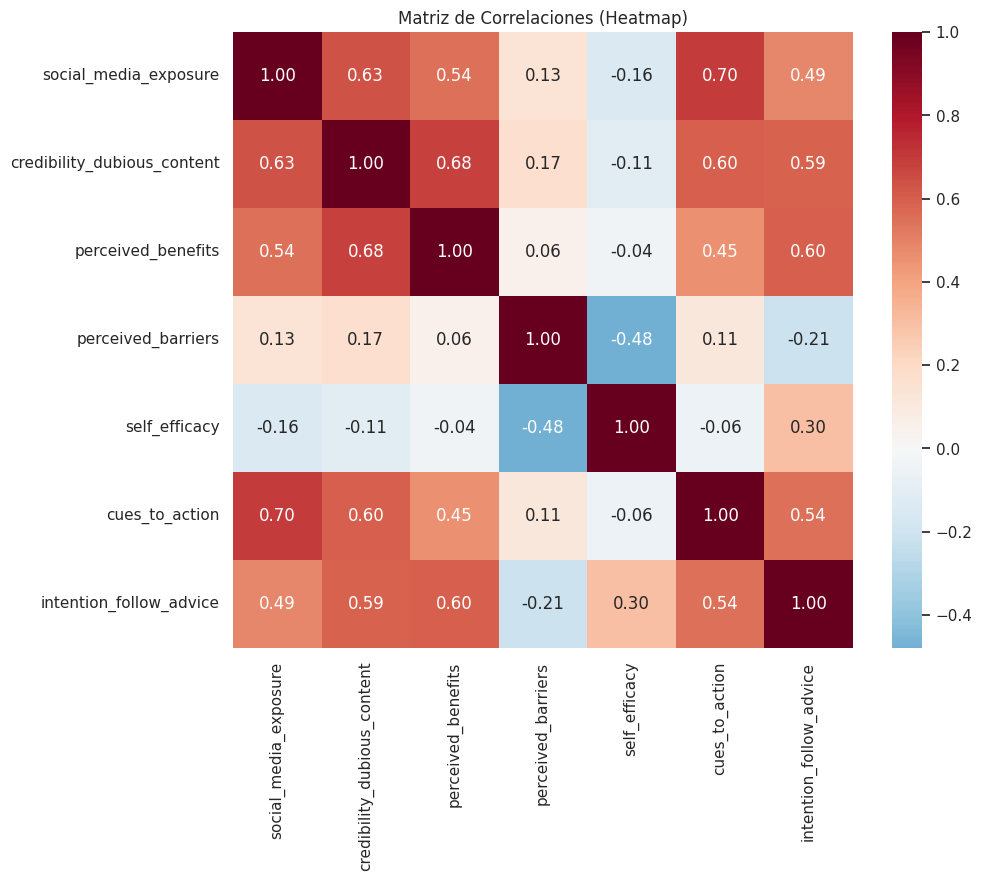

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlaciones (Heatmap)')
plt.show()


### Preguntas tutoriales

1. ¿Qué relación ves entre exposición en redes y credibilidad del contenido dudoso?
2. ¿Qué variables parecen más relacionadas con la intención de seguir consejos?
3. ¿Hay alguna correlación que te sorprenda o que te parezca contraintuitiva?



## 9. Regresión lineal

Vamos a predecir la variable continua **intention_follow_advice**.

Esto nos permite discutir qué variables parecen asociarse más claramente con la intención de seguir consejos nutricionales vistos en redes.


R2: 0.632
RMSE: 0.325


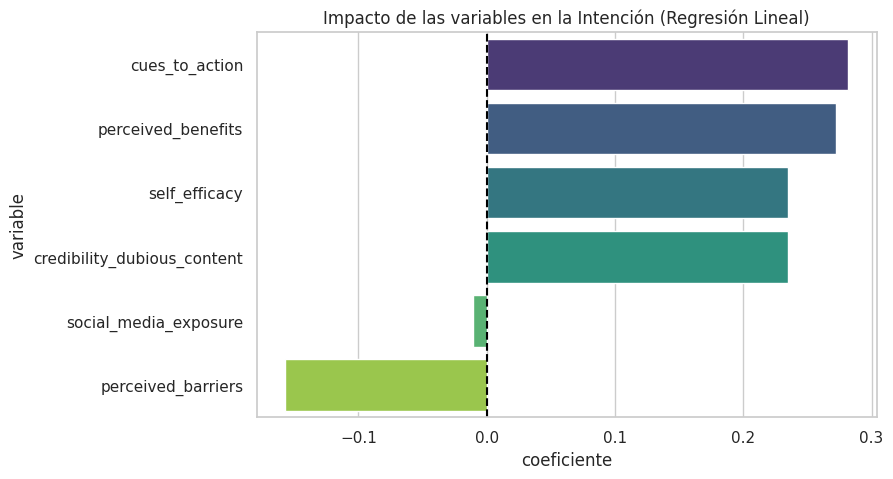

,variable,coeficiente
5,cues_to_action,0.281922
2,perceived_benefits,0.272274
4,self_efficacy,0.234964
1,credibility_dubious_content,0.234637
0,social_media_exposure,-0.010266
3,perceived_barriers,-0.157410


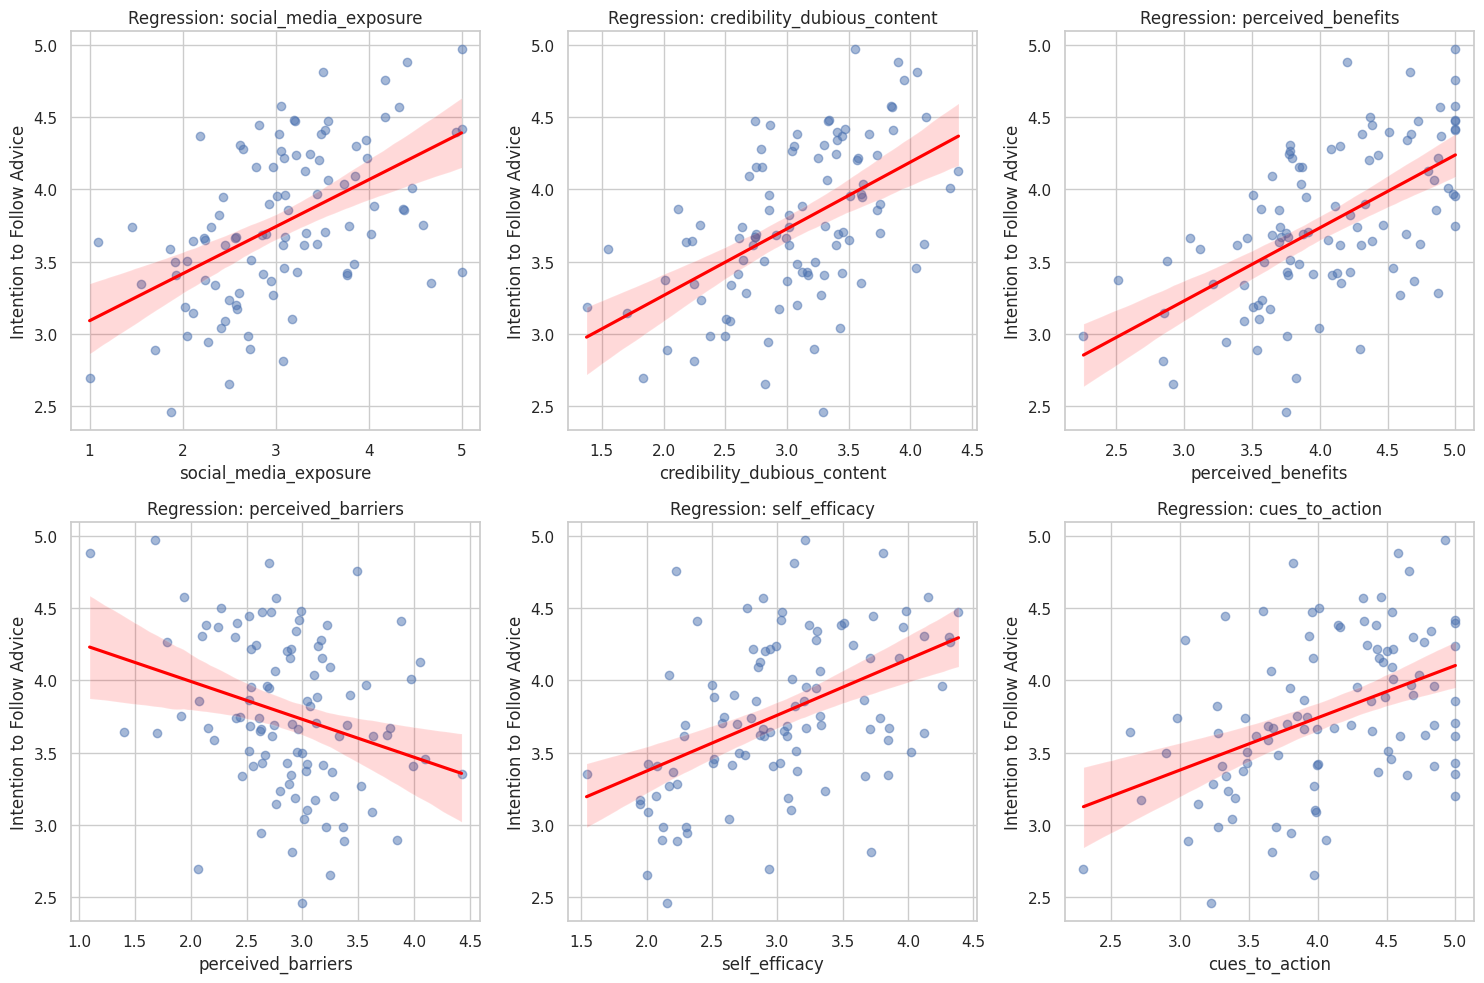

In [18]:
feature_cols = ['social_media_exposure', 'credibility_dubious_content', 'perceived_benefits',
                'perceived_barriers', 'self_efficacy', 'cues_to_action']

X = df[feature_cols]
y = df['intention_follow_advice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

print('R2:', round(r2_score(y_test, y_pred), 3))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))

coef_df = pd.DataFrame({
    'variable': feature_cols,
    'coeficiente': lin_model.coef_
}).sort_values('coeficiente', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='coeficiente', y='variable', palette='viridis', hue='variable', legend=False)
plt.title('Impacto de las variables en la Intención (Regresión Lineal)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

display(coef_df)

# Panel with actual regression lines for each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Using regplot to show the scatter points and the linear regression line for that specific feature
    sns.regplot(x=X_test[col], y=y_test, ax=axes[i],
                scatter_kws={'alpha':0.5},
                line_kws={'color':'red'})
    axes[i].set_title(f'Regression: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Intention to Follow Advice')

plt.tight_layout()
plt.show()


### Preguntas tutoriales

1. ¿Qué coeficientes son positivos y cuáles negativos?
2. ¿Coinciden esos signos con lo que esperabas según el modelo conceptual?
3. ¿Qué diferencia hay entre una variable muy correlacionada y una variable con un efecto ajustado en la regresión?



## 10. Clasificación básica

Ahora usamos la variable binaria **high_risk_following_intention**. El objetivo no es hacer un modelo predictivo sofisticado, sino comparar una lógica de clasificación con la lógica de la regresión anterior.


Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.83      0.82      0.82        65
           1       0.67      0.69      0.68        35

    accuracy                           0.77       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.77      0.77      0.77       100



/tmp/ipykernel_1415/1697477198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_clf, x='coef_logit', y='variable', palette='magma')


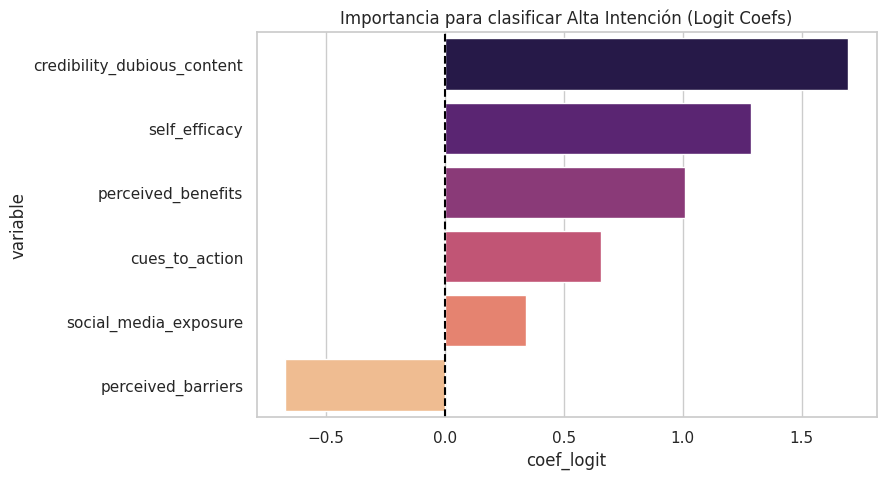

,variable,coef_logit
1,credibility_dubious_content,1.695952
4,self_efficacy,1.285727
2,perceived_benefits,1.010061
5,cues_to_action,0.656391
0,social_media_exposure,0.339409
3,perceived_barriers,-0.672877


In [16]:
X = df[feature_cols]
y = df['high_risk_following_intention']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

coef_clf = pd.DataFrame({
    'variable': feature_cols,
    'coef_logit': clf.coef_[0]
}).sort_values('coef_logit', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_clf, x='coef_logit', y='variable', palette='magma')
plt.title('Importancia para clasificar Alta Intención (Logit Coefs)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

display(coef_clf)


### Preguntas tutoriales

1. ¿Qué variables parecen más útiles para clasificar la alta intención de seguir consejos dudosos?
2. ¿En qué se parece y en qué se diferencia este resultado del obtenido con la regresión lineal?
3. ¿Qué gana y qué pierde la interpretación cuando pasamos de una puntuación continua a una clase binaria?



## 11. Qué estamos aprendiendo realmente

Este notebook no enseña solo a ejecutar código. Enseña algo más importante:

- que un modelo conceptual puede guiar la construcción de variables
- que unos datos sintéticos pueden seguir una lógica teórica
- que el análisis debe interpretarse a la luz del modelo y no al revés
- que una variable relacionada con desinformación puede incorporarse de forma explícita en un diseño docente

## Limitaciones

- Los datos no son reales.
- Las relaciones han sido diseñadas para enseñar, no para describir una población concreta.
- El modelo es deliberadamente simple.
- La variable de credibilidad del contenido dudoso es una adaptación docente, no una copia literal de un artículo concreto.



## 12. Extensiones posibles

Si más adelante quisieras enriquecer el notebook, podrías añadir:

- subgrupos de edad o nivel educativo
- interacción entre barreras y autoeficacia
- una medida más explícita de alfabetización en salud
- un segundo desenlace relacionado con uso de suplementos
- una comparación entre consejos saludables y consejos dudosos
